# Подробный анализ одного ROS 2 bag

Notebook декодирует выбранный прогон и показывает:

- положение ручки контроллера;
- скорости передней и задней тележек;
- GNSS master/rover как отдельный ground truth;
- временные шкалы и смещения `recorded_ns − header_ns`;
- локальную GNSS-траекторию в метрах;
- синхронизированное сравнение колесной и GNSS-скорости.

> Колёсные скорости и контроллер — разрешённые входы оценивателя. GNSS используется здесь исключительно для офлайн-аналитики и метрик.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from bag_analysis import (
    bag_topic_schema,
    build_speed_comparison,
    load_bag_frames,
    read_bag_metadata,
    speed_error_metrics,
    stream_timing_summary,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

## 1. Параметры

Измените `BAG_ID` и перезапустите все ячейки. Для первой проверки подходит короткий динамический прогон `30618_0d865417`.

In [2]:
BAG_ID = "30618_0d865417"
SYNC_TOLERANCE_MS = 150.0
WHEEL_DISAGREEMENT_THRESHOLD_MPS = 2.0

In [3]:
frames = load_bag_frames(BAG_ID)
metadata = pd.Series(read_bag_metadata(frames.bag_path))

print(f"Bag: {frames.bag_id}")
print(f"Поддерживаемых сообщений: {len(frames.records):,}")
display(metadata.to_frame("value"))

Bag: 30618_0d865417
Поддерживаемых сообщений: 1,075


,value
bag_id,30618_0d865417
vehicle_id,30618
duration_s,11.8409
start_ns,1785163494176007816
message_count,1075
size_mib,0.1328
control_count,286
front_wheel_count,115
rear_wheel_count,123
master_fix_count,142


## 2. Полная ROS-схема и наличие сообщений

`message_count` показывает, есть ли в топике реальные записи. Даже если топик объявлен в bag, счётчик может быть равен нулю. `field` раскрывает вложенные поля ROS-типа независимо от наличия сообщений.

In [ ]:
topic_schema = bag_topic_schema(BAG_ID)

topic_overview = (
    topic_schema.groupby(["topic", "message_type", "message_count"], as_index=False)
    .agg(fields=("field", lambda values: ", ".join(values)))
)

display(topic_overview)
display(topic_schema)

## 3. Структура нормализованных данных

In [4]:
table_sizes = pd.Series({
    "control": len(frames.control),
    "wheels": len(frames.wheels),
    "gnss_fix": len(frames.gnss_fix),
    "gnss_velocity": len(frames.gnss_velocity),
})

display(table_sizes.to_frame("rows"))
display(frames.records.head(10))

,rows
control,286
wheels,238
gnss_fix,286
gnss_velocity,265


,topic,recorded_ns,header_ns,recording_delay_ns,frame_id,kind,wheel_id,velocity_mps,velocity_finite,receiver,status,service,has_fix,coordinates_finite,latitude_deg,longitude_deg,altitude_m,position_covariance,position_covariance_type,position,velocity_components_finite,velocity_x_mps,velocity_y_mps,velocity_z_mps,horizontal_speed_mps,speed_3d_mps,time_s,recorded_time_s,delay_ms
0,/vehicle/rear_bogie_velocity,1785163494176007816,1785163490758805949,3417201867,base_link,wheel_velocity,rear_bogie,0.0000,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,3.4172,"3,417.2019"
1,/sensing/gnss/rover/fix,1785163494179362427,1785163491500000000,2679362427,gps,gnss_fix,NaN,NaN,NaN,rover,2.0000,1.0000,True,True,55.7949,37.3866,161.2292,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.7412,3.4206,"2,679.3624"
2,/vehicle/front_bogie_velocity,1785163494187801344,1785163491856490458,2331310886,base_link,wheel_velocity,front_bogie,0.0000,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0977,3.4290,"2,331.3109"
3,/vehicle/driver_position_cmd,1785163494187859867,1785163491766219939,2421639928,,control,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,1.0074,3.4291,"2,421.6399"
4,/sensing/gnss/master/fix,1785163494187905565,1785163491800000000,2387905565,gps,gnss_fix,NaN,NaN,NaN,master,2.0000,1.0000,True,True,55.7948,37.3865,161.1584,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0412,3.4291,"2,387.9056"
5,/sensing/gnss/master/vel,1785163494193098010,1785163491900000000,2293098010,gps,gnss_velocity,NaN,NaN,NaN,master,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,0.0046,0.0052,-0.0000,0.0070,0.0070,1.1412,3.4343,"2,293.0980"
6,/sensing/gnss/rover/vel,1785163494199312355,1785163493600000000,599312355,gps,gnss_velocity,NaN,NaN,NaN,rover,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,0.0051,0.0032,-0.0010,0.0060,0.0061,2.8412,3.4405,599.3124
7,/vehicle/rear_bogie_velocity,1785163494202383412,1785163490856765084,3345618328,base_link,wheel_velocity,rear_bogie,0.0000,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0980,3.4436,"3,345.6183"
8,/sensing/gnss/rover/fix,1785163494204409716,1785163491600000000,2604409716,gps,gnss_fix,NaN,NaN,NaN,rover,2.0000,1.0000,True,True,55.7949,37.3866,161.2268,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8412,3.4456,"2,604.4097"
9,/vehicle/front_bogie_velocity,1785163494204755627,1785163492060437296,2144318331,base_link,wheel_velocity,front_bogie,0.0000,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.3016,3.4459,"2,144.3183"


In [ ]:
field_presence_rows = []
for kind, part in frames.records.groupby("kind"):
    for column in part.columns:
        non_null = part[column].dropna()
        if not non_null.empty:
            sample = non_null.iloc[0]
            field_presence_rows.append({
                "kind": kind,
                "normalized_field": column,
                "pandas_dtype": str(part[column].dtype),
                "non_null_count": len(non_null),
                "example": str(sample)[:120],
            })

field_presence = pd.DataFrame(field_presence_rows)
field_presence

## 4. Время и качество потока

`header_ns` — время измерения из сообщения. `recorded_ns` — время записи сообщения в bag. Разность между ними может включать разные часы, стартовый backlog и транспортные задержки, поэтому это диагностический показатель, а не готовая оценка latency.

In [5]:
timing = stream_timing_summary(frames)
timing

,count,header_span_s,median_rate_hz,median_delay_ms,p95_delay_ms,negative_delay_count,header_reversal_count,duplicate_header_count
stream,,,,,,,,
control,286,14.2499,20.0011,1.0039,"1,838.0718",0,0,0
gnss_fix:master,142,14.1000,10.0000,40.7156,"1,759.7600",0,0,0
gnss_fix:rover,144,14.4000,10.0000,74.0105,"2,050.3720",0,0,0
gnss_velocity:master,141,14.0000,10.0000,80.6172,"1,665.0163",0,0,0
gnss_velocity:rover,124,12.3000,10.0000,87.1231,98.7442,0,0,0
wheel_velocity:front_bogie,115,14.0301,9.4372,79.3595,"1,701.3200",0,0,0
wheel_velocity:rear_bogie,123,15.1278,9.4378,89.3735,"2,773.0949",0,0,0


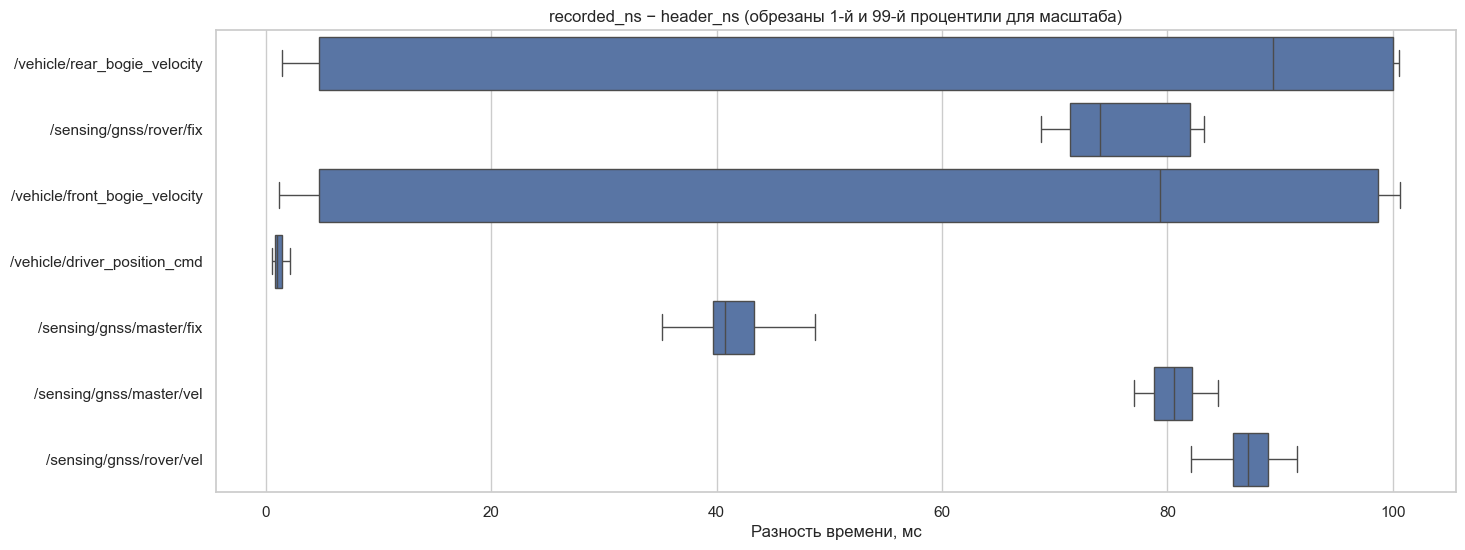

In [6]:
delay_plot = frames.records[["topic", "delay_ms"]].dropna().copy()
low, high = delay_plot["delay_ms"].quantile([0.01, 0.99])
delay_plot["delay_ms_clipped"] = delay_plot["delay_ms"].clip(low, high)

plt.figure(figsize=(16, 6))
sns.boxplot(delay_plot, x="delay_ms_clipped", y="topic", showfliers=False)
plt.title("recorded_ns − header_ns (обрезаны 1-й и 99-й процентили для масштаба)")
plt.xlabel("Разность времени, мс")
plt.ylabel("")
plt.show()

## 5. Все основные сигналы во времени

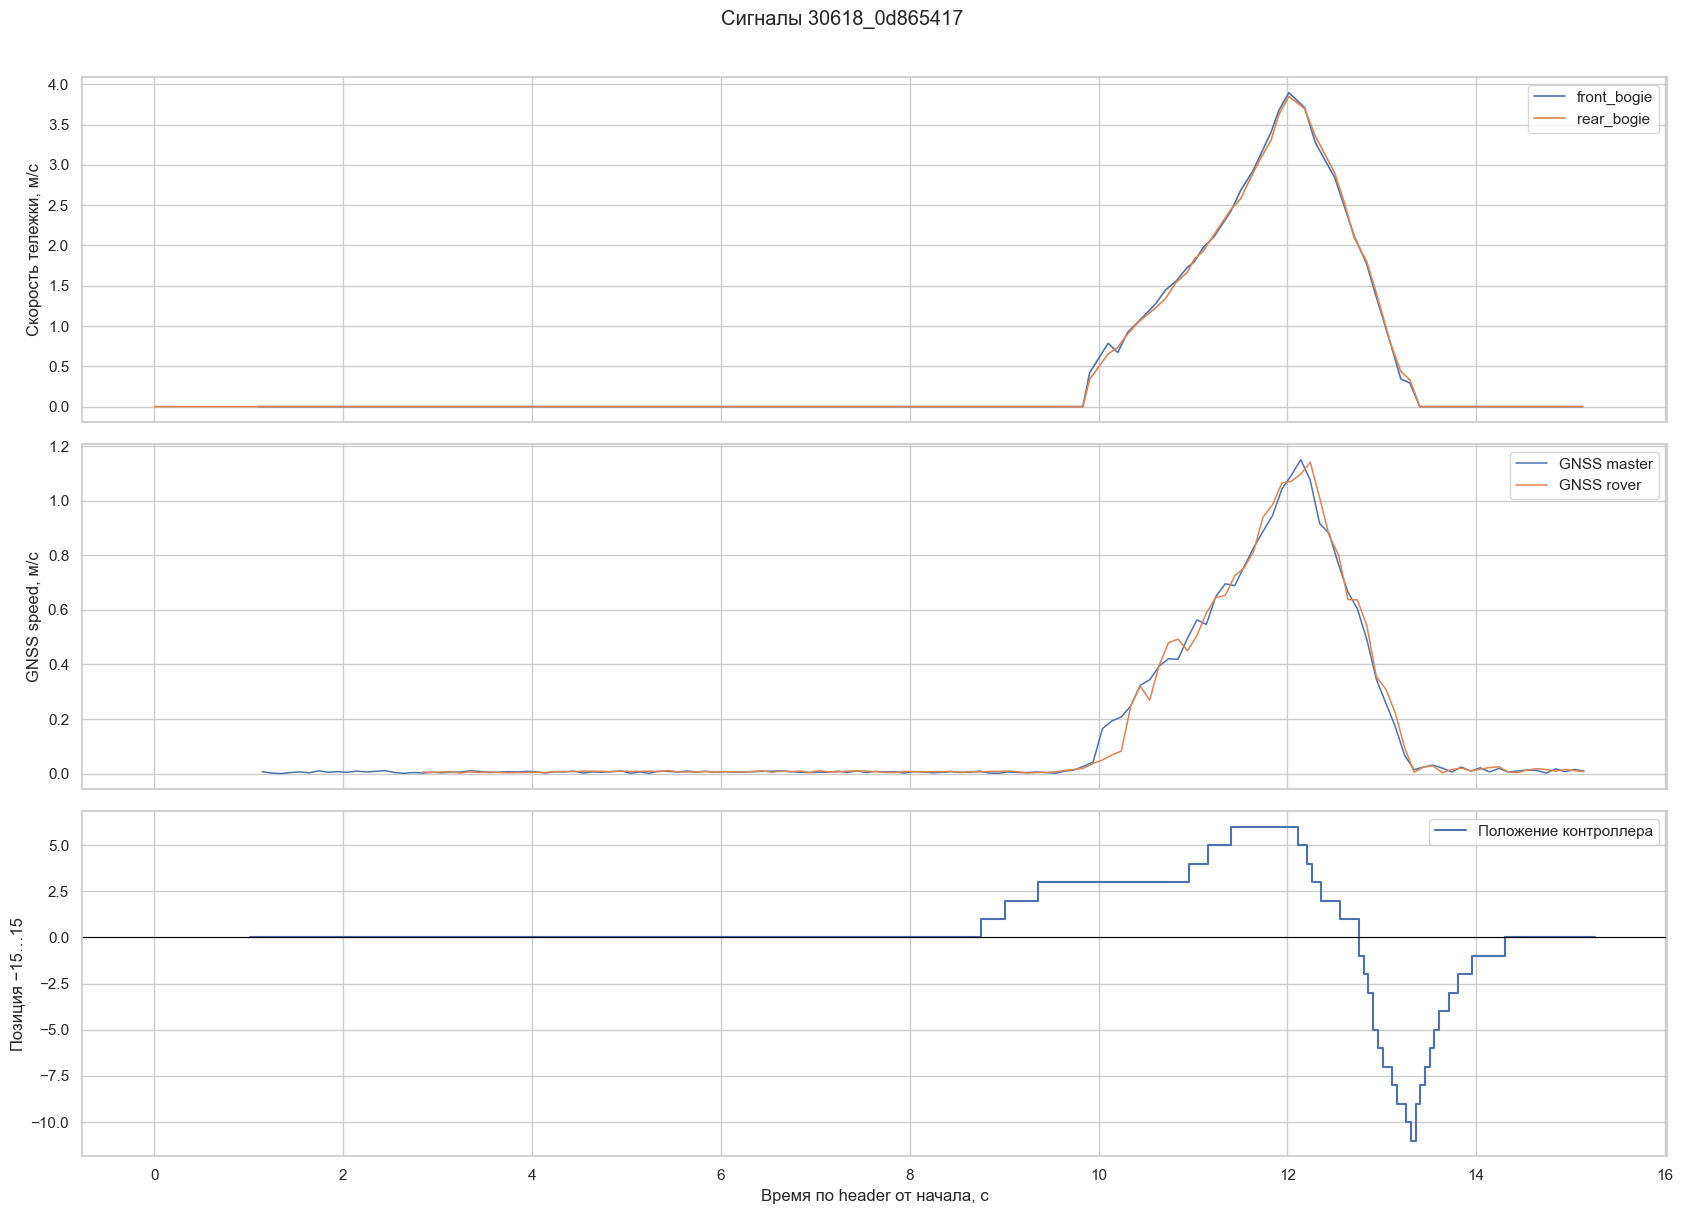

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(17, 12), sharex=True)

for wheel_id, part in frames.wheels.groupby("wheel_id"):
    axes[0].plot(part["time_s"], part["velocity_mps"], label=wheel_id, linewidth=1.2)
axes[0].set_ylabel("Скорость тележки, м/с")
axes[0].legend()

if not frames.gnss_velocity.empty:
    for receiver, part in frames.gnss_velocity.groupby("receiver"):
        axes[1].plot(
            part["time_s"],
            part["horizontal_speed_mps"],
            label=f"GNSS {receiver}",
            linewidth=1.1,
        )
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "В этом bag нет GNSS velocity", ha="center", va="center", transform=axes[1].transAxes)
axes[1].set_ylabel("GNSS speed, м/с")

axes[2].step(
    frames.control["time_s"],
    frames.control["position"],
    where="post",
    label="Положение контроллера",
)
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set(ylabel="Позиция −15…15", xlabel="Время по header от начала, с")
axes[2].legend()

fig.suptitle(f"Сигналы {BAG_ID}", y=1.01)
fig.tight_layout()
plt.show()

## 6. Согласованность тележек

wheel_id,front_bogie,rear_bogie,difference_mps
count,115.0000,123.0000,115.0000
mean,0.4946,0.4594,0.0033
std,1.0111,0.9788,0.0302
min,0.0000,0.0000,-0.0924
25%,0.0000,0.0000,0.0000
50%,0.0000,0.0000,0.0000
75%,0.1462,0.0000,0.0000
max,3.8969,3.8507,0.1323


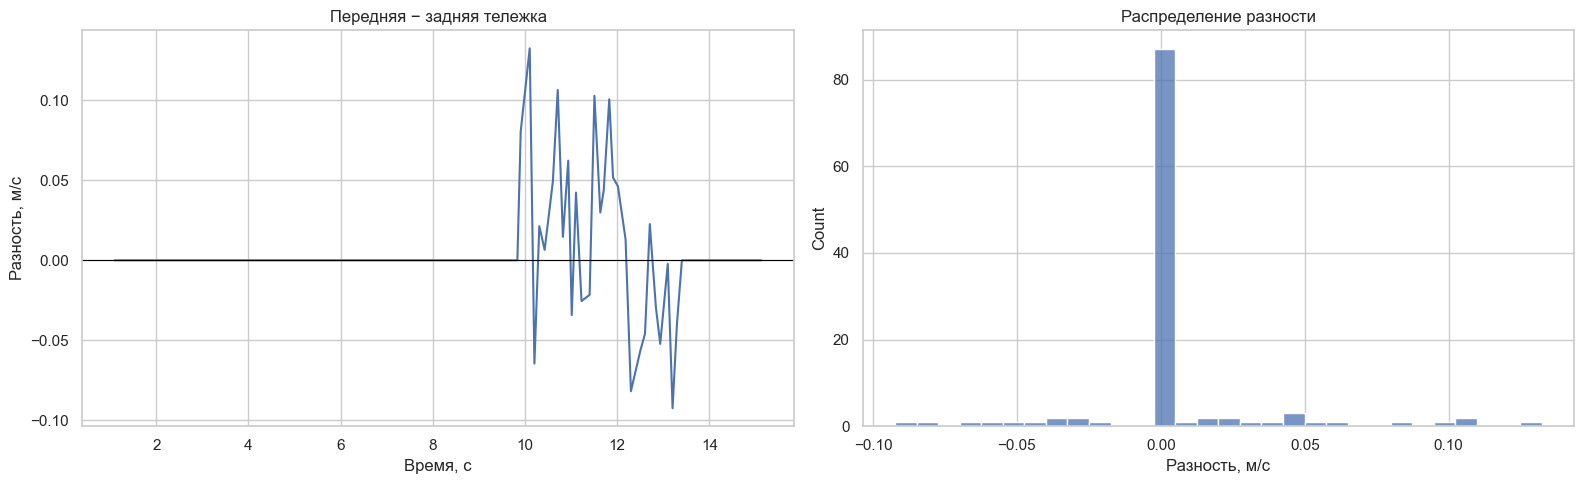

In [8]:
wheel_pair = (
    frames.wheels.pivot_table(
        index="header_ns",
        columns="wheel_id",
        values="velocity_mps",
        aggfunc="last",
    )
    .sort_index()
)
wheel_pair["time_s"] = (wheel_pair.index - frames.origin_ns) / 1e9

if {"front_bogie", "rear_bogie"}.issubset(wheel_pair.columns):
    wheel_pair["difference_mps"] = wheel_pair["front_bogie"] - wheel_pair["rear_bogie"]
    wheel_pair["abs_difference_mps"] = wheel_pair["difference_mps"].abs()
    display(wheel_pair[["front_bogie", "rear_bogie", "difference_mps"]].describe())

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].plot(wheel_pair["time_s"], wheel_pair["difference_mps"])
    axes[0].axhline(0, color="black", linewidth=0.8)
    axes[0].set(title="Передняя − задняя тележка", xlabel="Время, с", ylabel="Разность, м/с")
    sns.histplot(wheel_pair["difference_mps"].dropna(), bins=30, ax=axes[1])
    axes[1].set(title="Распределение разности", xlabel="Разность, м/с")
    fig.tight_layout()
    plt.show()
else:
    print("Нет синхронной пары front/rear для сравнения.")

## 7. GNSS-положение в локальной системе

Координаты преобразованы из WGS84 в локальную азимутальную проекцию относительно первого валидного `master` fix (или первого доступного fix). Это удобно для EDA, но перед использованием в метриках необходимо согласовать систему координат с контрактом жюри. `master` и `rover` — разные приёмники/точки, их нельзя автоматически считать одной позицией кузова.

Начало локальной системы: {'receiver': 'master', 'latitude_deg': 55.79482674333333, 'longitude_deg': 37.386513765, 'altitude_m': 161.1584}


,,,samples
receiver,status,position_covariance_type,
master,2.0000,0.0000,142
rover,2.0000,0.0000,144


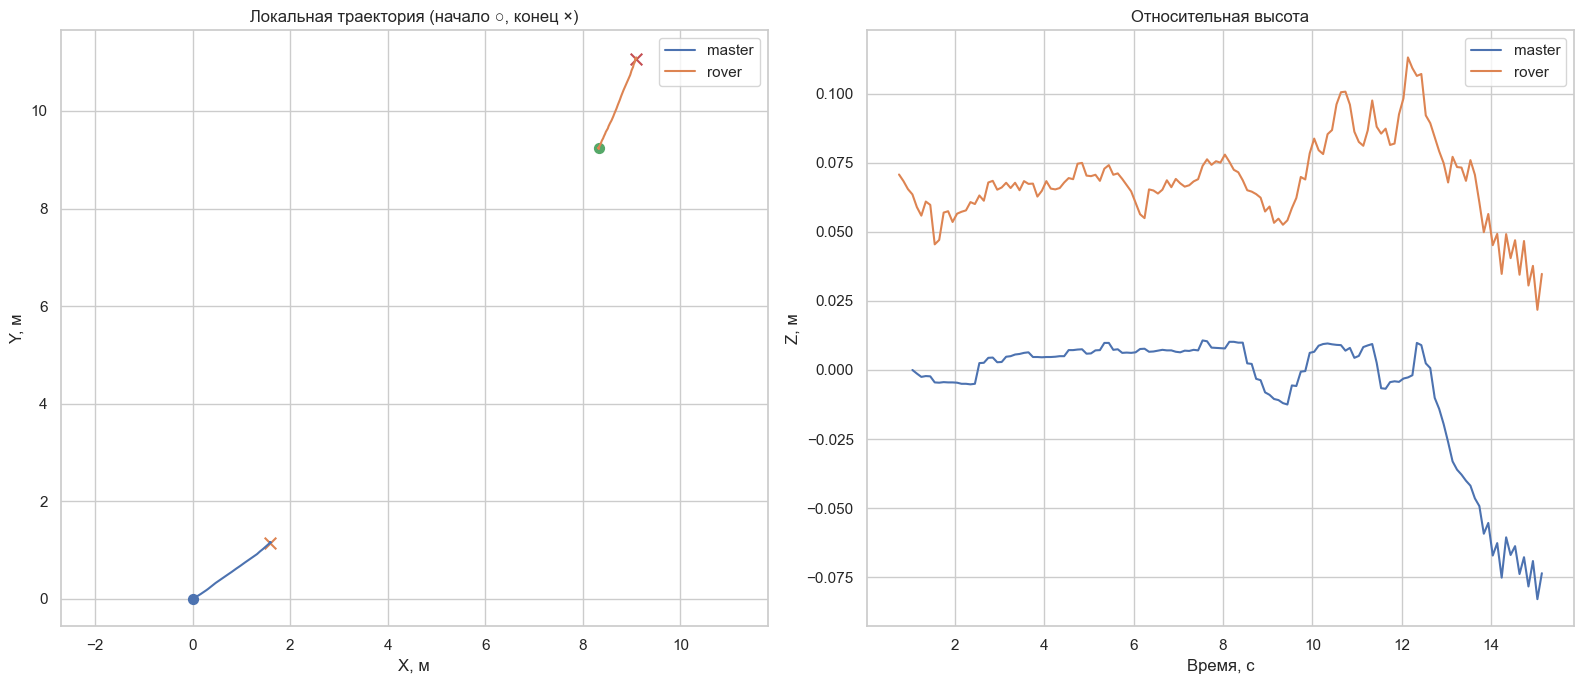

In [9]:
if frames.gnss_fix.empty or frames.gnss_fix["local_x_m"].notna().sum() == 0:
    print("В этом bag нет валидных GNSS fix.")
else:
    print("Начало локальной системы:", frames.gnss_fix.attrs.get("reference"))
    display(
        frames.gnss_fix.groupby(["receiver", "status", "position_covariance_type"], dropna=False)
        .size()
        .rename("samples")
        .to_frame()
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    for receiver, part in frames.gnss_fix.dropna(subset=["local_x_m", "local_y_m"]).groupby("receiver"):
        axes[0].plot(part["local_x_m"], part["local_y_m"], label=receiver)
        axes[0].scatter(part.iloc[0]["local_x_m"], part.iloc[0]["local_y_m"], marker="o", s=50)
        axes[0].scatter(part.iloc[-1]["local_x_m"], part.iloc[-1]["local_y_m"], marker="x", s=70)
        axes[1].plot(part["time_s"], part["local_z_m"], label=receiver)
    axes[0].set(title="Локальная траектория (начало ○, конец ×)", xlabel="X, м", ylabel="Y, м")
    axes[0].axis("equal")
    axes[0].legend()
    axes[1].set(title="Относительная высота", xlabel="Время, с", ylabel="Z, м")
    axes[1].legend()
    fig.tight_layout()
    plt.show()

## 8. Колёсная скорость против GNSS truth

GNSS даёт модуль горизонтальной скорости. Поэтому ниже с ним сравнивается **модуль медианы тележек**. Это описательная проверка датчиков, а не метрика готовой модели: знак движения теряется, а временная синхронизация выполняется ближайшим соседом в пределах `SYNC_TOLERANCE_MS`.

,value
paired_samples,115.0000
coverage,0.9350
mae_mps,0.3594
rmse_mps,0.7975
bias_mps,0.3480
p95_abs_error_mps,2.1126
correlation,0.9974


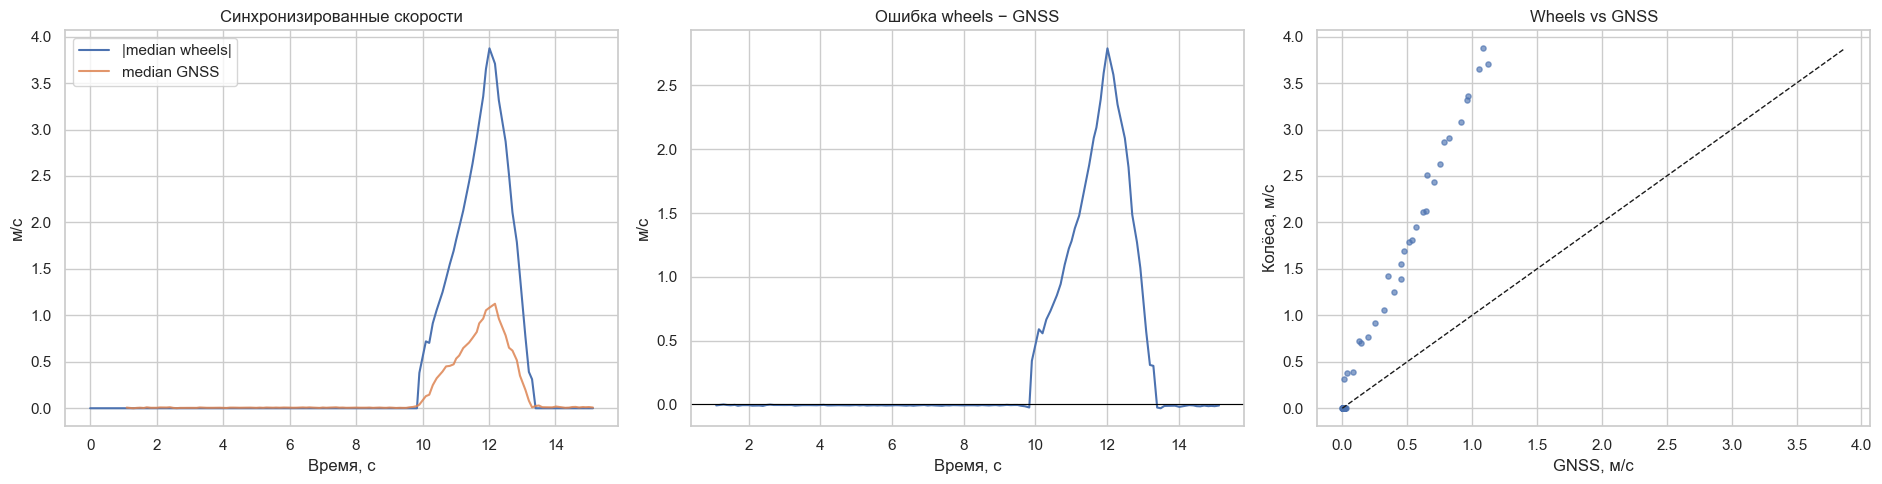

In [10]:
comparison = build_speed_comparison(frames, tolerance_ms=SYNC_TOLERANCE_MS)
metrics = speed_error_metrics(comparison)

if comparison.empty or metrics.empty:
    print("Недостаточно колесных или GNSS velocity данных для сравнения.")
else:
    display(metrics.to_frame("value"))

    fig, axes = plt.subplots(1, 3, figsize=(19, 5))
    axes[0].plot(comparison["time_s"], comparison["wheel_speed_magnitude_mps"], label="|median wheels|")
    axes[0].plot(comparison["time_s"], comparison["gnss_speed_mps"], label="median GNSS", alpha=0.85)
    axes[0].set(title="Синхронизированные скорости", xlabel="Время, с", ylabel="м/с")
    axes[0].legend()

    axes[1].plot(comparison["time_s"], comparison["speed_error_mps"])
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set(title="Ошибка wheels − GNSS", xlabel="Время, с", ylabel="м/с")

    paired = comparison.dropna(subset=["wheel_speed_magnitude_mps", "gnss_speed_mps"])
    axes[2].scatter(paired["gnss_speed_mps"], paired["wheel_speed_magnitude_mps"], s=14, alpha=0.65)
    limit = max(paired["gnss_speed_mps"].max(), paired["wheel_speed_magnitude_mps"].max())
    axes[2].plot([0, limit], [0, limit], "k--", linewidth=1)
    axes[2].set(title="Wheels vs GNSS", xlabel="GNSS, м/с", ylabel="Колёса, м/с")

    fig.tight_layout()
    plt.show()

## 9. Связь контроллера с динамикой GNSS

,samples,median_speed_mps,median_acceleration_mps2,acceleration_p10,acceleration_p90
position,,,,,
-11.0000,1,0.0095,-0.7200,-0.7200,-0.7200
-9.0000,1,0.0815,-1.1650,-1.1650,-1.1650
-8.0000,2,0.1110,-0.3600,-0.7640,0.0440
-7.0000,1,0.2845,-0.6650,-0.6650,-0.6650
-6.0000,1,0.0295,0.0550,0.0550,0.0550
-5.0000,1,0.3510,-1.6550,-1.6550,-1.6550
-4.0000,1,0.0115,-0.1800,-0.1800,-0.1800
-3.0000,1,0.0105,-0.0100,-0.0100,-0.0100
-2.0000,3,0.0220,-0.1250,-0.8570,0.0670


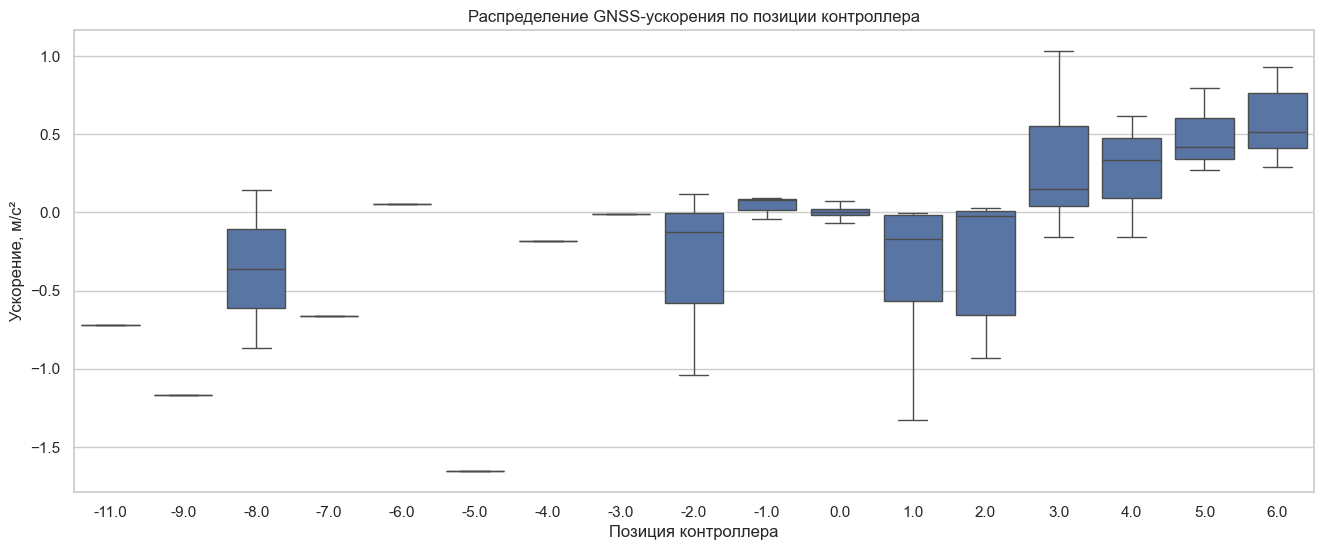

In [11]:
if frames.gnss_velocity.empty or frames.control.empty:
    print("Нет данных для анализа контроллера и GNSS.")
else:
    truth = (
        frames.gnss_velocity.pivot_table(
            index="header_ns",
            columns="receiver",
            values="horizontal_speed_mps",
            aggfunc="last",
        )
        .sort_index()
    )
    truth["speed_mps"] = truth.median(axis=1, skipna=True)
    truth = truth.reset_index()
    truth["dt_s"] = truth["header_ns"].diff() / 1e9
    truth["acceleration_mps2"] = truth["speed_mps"].diff() / truth["dt_s"]
    truth.loc[~truth["dt_s"].between(0.02, 1.0), "acceleration_mps2"] = np.nan

    dynamics = pd.merge_asof(
        truth.sort_values("header_ns"),
        frames.control[["header_ns", "position"]].sort_values("header_ns"),
        on="header_ns",
        direction="backward",
        tolerance=int(0.5e9),
    )

    controller_summary = dynamics.groupby("position").agg(
        samples=("speed_mps", "count"),
        median_speed_mps=("speed_mps", "median"),
        median_acceleration_mps2=("acceleration_mps2", "median"),
        acceleration_p10=("acceleration_mps2", lambda values: values.quantile(0.10)),
        acceleration_p90=("acceleration_mps2", lambda values: values.quantile(0.90)),
    )
    display(controller_summary)

    plt.figure(figsize=(16, 6))
    sns.boxplot(
        dynamics.dropna(subset=["position", "acceleration_mps2"]),
        x="position",
        y="acceleration_mps2",
        showfliers=False,
    )
    plt.title("Распределение GNSS-ускорения по позиции контроллера")
    plt.xlabel("Позиция контроллера")
    plt.ylabel("Ускорение, м/с²")
    plt.show()

## 10. Автоматические флаги для дальнейшего исследования

In [12]:
flags = {
    "negative_wheel_samples": int((frames.wheels["velocity_mps"] < 0).sum()),
    "non_finite_wheel_samples": int((~frames.wheels["velocity_finite"].eq(True)).sum()),
    "invalid_gnss_fixes": int((~frames.gnss_fix["has_fix"].eq(True)).sum()) if not frames.gnss_fix.empty else 0,
    "header_reversals": int(timing["header_reversal_count"].sum()),
    "duplicate_header_timestamps": int(timing["duplicate_header_count"].sum()),
}

if "abs_difference_mps" in wheel_pair:
    flags["large_wheel_disagreement_samples"] = int(
        (wheel_pair["abs_difference_mps"] > WHEEL_DISAGREEMENT_THRESHOLD_MPS).sum()
    )
else:
    flags["large_wheel_disagreement_samples"] = 0

pd.Series(flags).to_frame("count")

,count
negative_wheel_samples,0
non_finite_wheel_samples,0
invalid_gnss_fixes,0
header_reversals,0
duplicate_header_timestamps,0
large_wheel_disagreement_samples,0


## Интерпретация

- Большая разность тележек может означать буксование/юз, но также требует проверки времени и качества обоих каналов.
- GNSS covariance с типом `UNKNOWN` и нулевыми значениями нельзя трактовать как идеальную точность.
- GNSS horizontal speed не содержит знак движения; для знаковой продольной скорости нужна проекция вектора на направление пути.
- Для выводов о модели анализируйте несколько bag и разделяйте train/validation/test целыми сессиями.
- Все численные пороги в notebook — исследовательские параметры, а не готовые safety-пороги production-системы.